# Synthetic MV Ternary-Tree UQ Scaling

## tl;dr

This benchmark compares deterministic SE, analytical UQ, and Monte Carlo UQ on the original balanced ternary MV radial tree. The network sizes are 10, 50, 100, 500, 1,000, 2,000, and 5,000 buses. Monte Carlo is evaluated with `N = 30`, `100`, and `1,000` samples, and both logarithmic and linear-time figures are exported. In the recorded 5,000-bus run, deterministic ILSE/NRSE took approximately 0.02/0.04 s, analytical UQ ILSE/NRSE 1.07/1.49 s, and Monte Carlo ILSE/NRSE 0.85/0.99 s for N=30 versus 27.69/27.74 s for N=1,000.

## Context & Methods

The real networks used by the other examples have different sizes, depths, measurement layouts, and electrical parameters. This notebook controls those factors by generating balanced ternary radial trees with the same MV electrical model and sensor layout for every size.

The benchmark reports:

1. deterministic ILSE and NRSE without uncertainty propagation;
2. analytical UQ ILSE and NRSE with uncertainty propagation; and
3. Monte Carlo ILSE and NRSE with `N = 30`, `100`, and `1,000` perturbed measurement samples.

### Solver and uncertainty distinction

| Method | Solver | Uncertainty calculation | Output |
|---|---|---|---|
| Deterministic ILSE | Iterative linear | No | Estimated voltages, currents, powers |
| Analytical UQ ILSE | Iterative linear | Yes, via Jacobian/covariance propagation | Estimates + analytical sigmas |
| Analytical UQ NRSE | Newton–Raphson | Yes, via Jacobian/covariance propagation | Estimates + analytical sigmas |

Deterministic and analytical UQ ILSE use the same iterative-linear estimator; the analytical version additionally computes propagated uncertainty. Analytical UQ NRSE uses the Newton–Raphson estimator and also computes propagated uncertainty.

### Key assumptions

- Every non-root bus has one fixed-PQ load; there are no PV generators or voltage regulators.
- The root is a 20 kV slack/source bus and each branch is active, producing a radial network.
- Each branching node has three children, so branching occurs at every depth level.
- Four voltage-magnitude measurements are spread across the tree, including the root; one P/Q power sensor is placed at the to-terminal of every branch.
- Measurements are initialized at the deterministic power-flow solution; uncertainty enters through the configured sensor sigmas and Monte Carlo updates.
- Network construction, deterministic power flow, sensor creation, and Monte Carlo update generation are excluded from the timed SE/UQ solver calls.
- The Monte Carlo sample count is varied explicitly because its computational cost is expected to scale with `N`.

In [1]:
# ruff: noqa: E501
import sys
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import power_grid_model
from power_grid_model import (
    AttributeType,
    CalculationMethod,
    CalculationType,
    ComponentType,
    DatasetType,
    LoadGenType,
    MeasuredTerminalType,
    PowerGridModel,
    initialize_array,
)
from power_grid_model._core.power_grid_model_c.get_pgm_dll_path import get_pgm_dll_path
from power_grid_model.utils import create_state_estimation_monte_carlo_updates
from power_grid_model.validation import assert_valid_input_data

output_directory = (
    Path("docs/examples/output/synthetic_mv_ternary_tree_uq_scaling")
    if Path("docs/examples").is_dir()
    else Path("output/synthetic_mv_ternary_tree_uq_scaling")
)
output_directory.mkdir(parents=True, exist_ok=True)
figure_directory = output_directory / "figures"
figure_directory.mkdir(parents=True, exist_ok=True)

node_counts = [10, 50, 100, 500, 1_000, 2_000, 5_000]
monte_carlo_sample_counts = [30, 100, 1_000]
timing_repeats = 1
solver_error_tolerance = 1e-4
solver_max_iterations = 100

print("Python:", sys.executable)
print("Power Grid Model package:", power_grid_model.__file__)
print("Native library:", get_pgm_dll_path())
print("Node counts:", node_counts)
print("Monte Carlo samples per size:", monte_carlo_sample_counts)

Python: /home/jhe/pgm_dev/power-grid-model/.venv/bin/python
Power Grid Model package: /home/jhe/pgm_dev/power-grid-model/src/power_grid_model/__init__.py
Native library: /home/jhe/pgm_dev/power-grid-model/build/bin/libpower_grid_model_c.so
Node counts: [10, 50, 100, 500, 1000, 2000, 5000]
Monte Carlo samples per size: [30, 100, 1000]


## Generate synthetic MV networks

A node with index `i > 0` has parent `(i - 1) // 3`. This creates the original balanced ternary tree: the root has three children, every next-level node has three children, and the final level is truncated to obtain the exact requested node count.

In [2]:
def build_ternary_mv_network(node_count):
    """Build an exact-size balanced ternary radial network at 20 kV."""
    if node_count < 2:
        raise ValueError("The synthetic network needs at least two buses.")

    node = initialize_array(DatasetType.input, ComponentType.node, node_count)
    node[AttributeType.id] = np.arange(node_count)
    node[AttributeType.u_rated] = 20_000.0

    line_count = node_count - 1
    child_ids = np.arange(1, node_count)
    line = initialize_array(DatasetType.input, ComponentType.line, line_count)
    line[AttributeType.id] = np.arange(node_count, node_count + line_count)
    line[AttributeType.from_node] = (child_ids - 1) // 3
    line[AttributeType.to_node] = child_ids
    line[AttributeType.from_status] = 1
    line[AttributeType.to_status] = 1
    line[AttributeType.r1] = 0.04
    line[AttributeType.x1] = 0.08
    line[AttributeType.c1] = 0.0
    line[AttributeType.tan1] = 0.0
    line[AttributeType.i_n] = 1.0e9
    line[AttributeType.r0] = 0.04
    line[AttributeType.x0] = 0.08
    line[AttributeType.c0] = 0.0
    line[AttributeType.tan0] = 0.0

    load = initialize_array(DatasetType.input, ComponentType.sym_load, line_count)
    load[AttributeType.id] = np.arange(node_count + line_count, node_count + 2 * line_count)
    load[AttributeType.node] = child_ids
    load[AttributeType.status] = 1
    load[AttributeType.type] = LoadGenType.const_power
    load_scale = 1.0 + 0.15 * np.sin(0.37 * child_ids)
    load[AttributeType.p_specified] = 1_000.0 * load_scale
    load[AttributeType.q_specified] = 300.0 * load_scale

    source = initialize_array(DatasetType.input, ComponentType.source, 1)
    source[AttributeType.id] = [node_count + 2 * line_count]
    source[AttributeType.node] = [0]
    source[AttributeType.status] = [1]
    source[AttributeType.u_ref] = [1.0]
    if "u_ref_angle" in source.dtype.names:
        source[AttributeType.u_ref_angle] = [0.0]

    depth = np.zeros(node_count, dtype=int)
    for child_id in child_ids:
        depth[child_id] = depth[(child_id - 1) // 3] + 1

    return {
        ComponentType.node: node,
        ComponentType.line: line,
        ComponentType.sym_load: load,
        ComponentType.source: source,
    }, int(depth.max())


def make_state_estimation_input(base_input_data):
    """Create an IEEE33-style sensor layout from one deterministic power flow."""
    power_flow = PowerGridModel(base_input_data, system_frequency=50.0).calculate_power_flow(
        symmetric=True,
        calculation_method=CalculationMethod.newton_raphson,
        error_tolerance=1e-8,
        max_iterations=100,
    )
    input_data = {component: values.copy() for component, values in base_input_data.items()}
    node_ids = input_data[ComponentType.node][AttributeType.id].astype(int)
    line = input_data[ComponentType.line]
    line_ids = line[AttributeType.id].astype(int)
    voltage_sensor_ids = np.unique(
        np.linspace(0, len(node_ids) - 1, min(4, len(node_ids)), dtype=int)
    )
    voltage_index = voltage_sensor_ids.astype(int)

    voltage_sensor = initialize_array(
        DatasetType.input, ComponentType.sym_voltage_sensor, len(voltage_sensor_ids)
    )
    voltage_sensor[AttributeType.id] = np.arange(100_000, 100_000 + len(voltage_sensor_ids))
    voltage_sensor[AttributeType.measured_object] = voltage_sensor_ids
    voltage_sensor[AttributeType.u_sigma] = 30.0
    voltage_sensor[AttributeType.u_measured] = power_flow[ComponentType.node][AttributeType.u][voltage_index]
    voltage_sensor[AttributeType.u_angle_measured] = np.nan
    voltage_sensor[AttributeType.u_angle_measured][0] = power_flow[ComponentType.node][AttributeType.u_angle][0]

    power_sensor = initialize_array(
        DatasetType.input, ComponentType.sym_power_sensor, len(line_ids)
    )
    power_sensor[AttributeType.id] = np.arange(
        100_000 + len(voltage_sensor_ids),
        100_000 + len(voltage_sensor_ids) + len(line_ids),
    )
    power_sensor[AttributeType.measured_object] = line_ids
    power_sensor[AttributeType.measured_terminal_type] = MeasuredTerminalType.branch_to
    power_sensor[AttributeType.p_sigma] = 25_000.0
    power_sensor[AttributeType.q_sigma] = 10_000.0
    power_sensor[AttributeType.p_measured] = power_flow[ComponentType.line][AttributeType.p_to]
    power_sensor[AttributeType.q_measured] = power_flow[ComponentType.line][AttributeType.q_to]

    input_data[ComponentType.sym_voltage_sensor] = voltage_sensor
    input_data[ComponentType.sym_power_sensor] = power_sensor
    return input_data


benchmark_inputs = {}
network_rows = []
for node_count in node_counts:
    base_input_data, depth = build_ternary_mv_network(node_count)
    state_estimation_input = make_state_estimation_input(base_input_data)
    assert_valid_input_data(
        state_estimation_input,
        calculation_type=CalculationType.state_estimation,
        symmetric=True,
    )
    benchmark_inputs[node_count] = state_estimation_input
    network_rows.append(
        {
            "buses": node_count,
            "lines": len(base_input_data[ComponentType.line]),
            "maximum depth": depth,
            "voltage sensors": len(state_estimation_input[ComponentType.sym_voltage_sensor]),
            "power sensors": len(state_estimation_input[ComponentType.sym_power_sensor]),
        }
    )

network_summary = pd.DataFrame(network_rows)
network_summary

,buses,lines,maximum depth,voltage sensors,power sensors
0,10,9,2,4,9
1,50,49,4,4,49
2,100,99,4,4,99
3,500,499,6,4,499
4,1000,999,6,4,999
5,2000,1999,7,4,1999
6,5000,4999,8,4,4999


## Time the SE and UQ methods

The measured interval starts immediately before `calculate_state_estimation()` and ends after the returned result is available. Each case receives one unmeasured warm-up call and then one measured call; the table reports that measured time in the median, minimum, and maximum columns. The same Monte Carlo update batch is reused for ILSE and NRSE at each sample count and network size.

In [3]:
deterministic_methods = {
    "Deterministic ILSE": CalculationMethod.iterative_linear,
    "Deterministic NRSE": CalculationMethod.newton_raphson,
}
analytical_methods = {
    "Analytical UQ ILSE": CalculationMethod.iterative_linear,
    "Analytical UQ NRSE": CalculationMethod.newton_raphson,
}
monte_carlo_methods = {
    "Monte Carlo ILSE": CalculationMethod.iterative_linear,
    "Monte Carlo NRSE": CalculationMethod.newton_raphson,
}

monte_carlo_updates = {
    (sample_count, node_count): create_state_estimation_monte_carlo_updates(
        input_data, sample_count, seed=2026
    )
    for sample_count in monte_carlo_sample_counts
    for node_count, input_data in benchmark_inputs.items()
}


def calculate_once(input_data, calculation_method, uq_kind, updates=None):
    model = PowerGridModel(input_data, system_frequency=50.0)
    if uq_kind == "deterministic":
        return model.calculate_state_estimation(
            calculation_method=calculation_method,
            error_tolerance=solver_error_tolerance,
            max_iterations=solver_max_iterations,
        )
    if uq_kind == "analytical":
        return model.calculate_state_estimation(
            calculation_method=calculation_method,
            calculate_uncertainty=True,
            error_tolerance=solver_error_tolerance,
            max_iterations=solver_max_iterations,
        )
    result = model.calculate_state_estimation(
        calculation_method=calculation_method,
        update_data=updates,
        error_tolerance=solver_error_tolerance,
        max_iterations=solver_max_iterations,
        continue_on_batch_error=True,
    )
    if model.batch_error is not None and model.batch_error.failed_scenarios:
        raise RuntimeError(
            f"Monte Carlo failed for scenarios {model.batch_error.failed_scenarios[:10]}"
        )
    return result


def median_timing(input_data, calculation_method, uq_kind, updates=None):
    calculate_once(input_data, calculation_method, uq_kind, updates)
    elapsed = []
    for _ in range(timing_repeats):
        start = perf_counter()
        calculate_once(input_data, calculation_method, uq_kind, updates)
        elapsed.append(perf_counter() - start)
    return float(np.median(elapsed)), float(np.min(elapsed)), float(np.max(elapsed))


timing_rows = []
for node_count, input_data in benchmark_inputs.items():
    for method_name, calculation_method in deterministic_methods.items():
        median_seconds, minimum_seconds, maximum_seconds = median_timing(
            input_data, calculation_method, "deterministic"
        )
        timing_rows.append(
            {
                "buses": node_count,
                "method": method_name,
                "Monte Carlo samples": np.nan,
                "median time [s]": median_seconds,
                "minimum time [s]": minimum_seconds,
                "maximum time [s]": maximum_seconds,
            }
        )

    for method_name, calculation_method in analytical_methods.items():
        median_seconds, minimum_seconds, maximum_seconds = median_timing(
            input_data, calculation_method, "analytical"
        )
        timing_rows.append(
            {
                "buses": node_count,
                "method": method_name,
                "Monte Carlo samples": np.nan,
                "median time [s]": median_seconds,
                "minimum time [s]": minimum_seconds,
                "maximum time [s]": maximum_seconds,
            }
        )

    for sample_count in monte_carlo_sample_counts:
        for method_name, calculation_method in monte_carlo_methods.items():
            median_seconds, minimum_seconds, maximum_seconds = median_timing(
                input_data,
                calculation_method,
                "monte_carlo",
                monte_carlo_updates[sample_count, node_count],
            )
            timing_rows.append(
                {
                    "buses": node_count,
                    "method": f"{method_name} (N={sample_count:,})",
                    "Monte Carlo samples": sample_count,
                    "median time [s]": median_seconds,
                    "minimum time [s]": minimum_seconds,
                    "maximum time [s]": maximum_seconds,
                }
            )

timing_results = pd.DataFrame(timing_rows)
timing_file = output_directory / "synthetic_mv_ternary_tree_uq_timing.csv"
timing_results.to_csv(timing_file, index=False)
print(f"Timing results exported to {timing_file}")
timing_results[timing_results["buses"] == max(node_counts)][
    ["method", "Monte Carlo samples", "median time [s]"]
].round(3)

deterministic_nrse_times = (
    timing_results[timing_results["method"] == "Deterministic NRSE"]
    .set_index("buses")["median time [s]"]
)
uq_timing_ratios = timing_results[
    timing_results["method"].str.startswith(("Analytical UQ", "Monte Carlo"))
].copy()
uq_timing_ratios["time / deterministic NRSE time"] = (
    uq_timing_ratios["median time [s]"]
    / uq_timing_ratios["buses"].map(deterministic_nrse_times)
)
uq_timing_ratio_table = (
    uq_timing_ratios.pivot(
        index="buses",
        columns="method",
        values="time / deterministic NRSE time",
    )
    .sort_index()
    .round(2)
)
uq_timing_ratio_table

Timing results exported to output/synthetic_mv_ternary_tree_uq_scaling/synthetic_mv_ternary_tree_uq_timing.csv


method,Analytical UQ ILSE,Analytical UQ NRSE,"Monte Carlo ILSE (N=1,000)",Monte Carlo ILSE (N=100),Monte Carlo ILSE (N=30),"Monte Carlo NRSE (N=1,000)",Monte Carlo NRSE (N=100),Monte Carlo NRSE (N=30)
buses,,,,,,,,
10,0.99,1.04,35.67,4.69,2.37,49.16,5.97,2.76
50,1.40,1.62,100.74,11.92,4.43,159.05,17.37,6.15
100,2.17,2.82,158.94,18.02,6.26,240.91,25.32,8.68
500,10.88,15.40,363.52,34.97,12.28,496.05,49.84,16.86
1000,14.81,20.46,375.62,37.25,20.18,745.82,76.53,14.93
2000,30.84,43.59,1102.02,85.18,29.52,842.49,98.32,28.97
5000,26.34,36.20,702.81,73.26,16.59,534.88,80.72,23.00


## Results

The notebook exports two views of the same timing data: the existing log-log figure and a companion figure with a linear time axis. Both retain a logarithmic bus-count axis so that all requested network sizes remain readable. Deterministic and analytical SE are shown alongside Monte Carlo ILSE and NRSE for `N = 30`, `100`, and `1,000`. The timing results also include a table of each UQ method's median time divided by deterministic NRSE time. The exported CSV contains the median, minimum, and maximum timing for every network size and method.

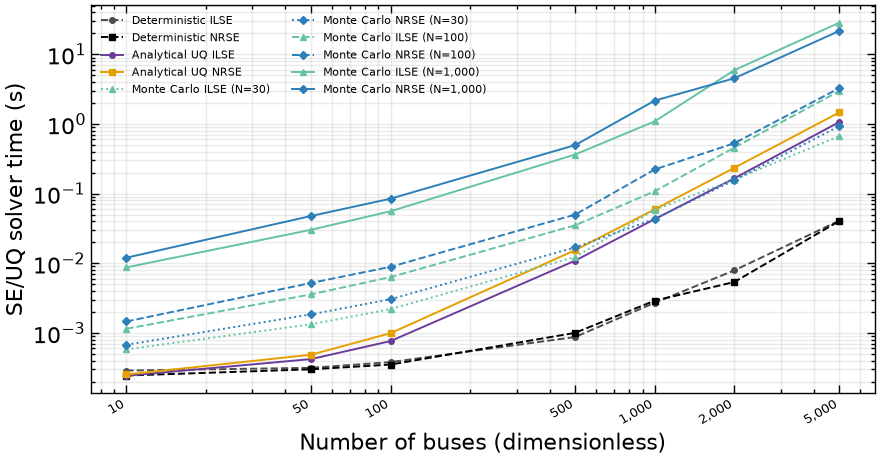

Log-log figure exported to output/synthetic_mv_ternary_tree_uq_scaling/figures


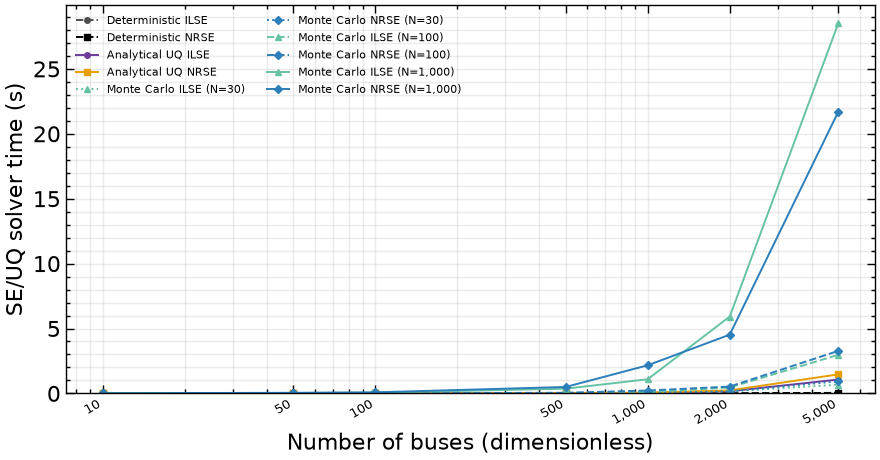

Linear-time figure exported to output/synthetic_mv_ternary_tree_uq_scaling/figures


In [4]:
try:
    import scienceplots  # noqa: F401
except ImportError:
    plot_style = ["default"]
else:
    plot_style = ["science", "notebook"]

plot_specs = [
    ("Deterministic ILSE", "#4D4D4D", "--", "o"),
    ("Deterministic NRSE", "#000000", "--", "s"),
    ("Analytical UQ ILSE", "#6A3D9A", "-", "o"),
    ("Analytical UQ NRSE", "#E69F00", "-", "s"),
]
for sample_count, line_style in [(30, ":"), (100, "--"), (1_000, "-")]:
    plot_specs.extend(
        [
            (f"Monte Carlo ILSE (N={sample_count:,})", "#66C2A5", line_style, "^"),
            (f"Monte Carlo NRSE (N={sample_count:,})", "#2C7FB8", line_style, "D"),
        ]
    )


def plot_scaling_figure(scale_name, use_log_y, file_stem):
    with plt.style.context(plot_style), plt.rc_context({"text.usetex": False}):
        figure, axis = plt.subplots(figsize=(9.0, 4.8))
        for method_name, color, line_style, marker in plot_specs:
            subset = timing_results[timing_results["method"] == method_name].sort_values("buses")
            axis.plot(
                subset["buses"],
                subset["median time [s]"],
                label=method_name,
                color=color,
                linestyle=line_style,
                marker=marker,
                linewidth=1.4,
                markersize=4,
            )
        axis.set_xscale("log")
        if use_log_y:
            axis.set_yscale("log")
        else:
            axis.set_ylim(0, timing_results["median time [s]"].max() * 1.05)
        axis.set_xlabel("Number of buses (dimensionless)")
        axis.set_ylabel("SE/UQ solver time (s)")
        axis.set_xticks(node_counts)
        axis.set_xticklabels([f"{count:,}" for count in node_counts])
        plt.setp(axis.get_xticklabels(), rotation=30, ha="right", fontsize=9)
        axis.grid(True, which="both", alpha=0.25)
        axis.legend(fontsize=8, ncol=2)
        figure.tight_layout()
        figure.savefig(figure_directory / f"{file_stem}.pdf")
        figure.savefig(figure_directory / f"{file_stem}.svg")
        figure.savefig(figure_directory / f"{file_stem}.png", dpi=300)
        plt.show()
        plt.close(figure)
        print(f"{scale_name} figure exported to {figure_directory}")


plot_scaling_figure(
    "Log-log",
    use_log_y=True,
    file_stem="synthetic_mv_ternary_tree_uq_scaling",
)
plot_scaling_figure(
    "Linear-time",
    use_log_y=False,
    file_stem="synthetic_mv_ternary_tree_uq_scaling_linear_scale",
)

## Takeaways

The figures compare deterministic SE, analytical UQ, and Monte Carlo UQ at three sample counts. For 5,000 buses, the recorded median times were approximately 0.02 s (deterministic ILSE), 0.04 s (deterministic NRSE), 1.07 s (analytical UQ ILSE), 1.49 s (analytical UQ NRSE), 0.85/0.99 s for Monte Carlo ILSE/NRSE with N=30, 2.77/2.80 s with N=100, and 27.69/27.74 s with N=1,000. The log-log view emphasizes scaling; the linear-time view emphasizes absolute runtime differences.